In [21]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict, Literal

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    get_NA_prediction_path,
    get_ckpt_eval_scores,
    find_batchnorm_pred_path,
    MODEL_ABBREVIATIONS_TO_DATASET,
)

from pytorch3dunet.unet3d.config import (
    load_config_direct #pyright: ignore[reportUnknownVariableType]
)

In [22]:
approach_mapping = {
    "DO": "feature_perturbation",
    "def": "default_selftraining",
    "cfd": "confidence_threshold",
    "F1": "direct_eval",
    "torchem": "supervised_torchem",
    "_SF_": "supervised",
    "ST": "supervised_training",
}

In [23]:
models: Dict[str, List[str]] = {
    "HtoE": [
        "HmtoE_model4_AdaBN_def",
        "HmtoE_model_NA2_AdaBN_def",
        "HmtoE_model_Res1_AdaBN_def",
        "HmtoE_model4_AdaBN_F108",
        "HmtoE_model_NA2_AdaBN_F108",
        "HmtoE_model_Res1_AdaBN_F108",
        #"HmtoE_model_Unetr2_def",
    ],
    "RtoE": [
        "RmtoE_model4_AdaBN_def",
        "RmtoE_model_NA2_AdaBN_def",
        "RmtoE_model_Res1_AdaBN_def",
        "RmtoE_model4_AdaBN_F108",
        "RmtoE_model_NA2_AdaBN_F108",
        "RmtoE_model_Res1_AdaBN_F108",
        #"RmtoE_model_Unetr2_def",
    ],
    "VtoE": [
        "VtoE_model2_AdaBN_def",
        "VtoE_model_NA2_AdaBN_def",
        "VtoE_model_Res1_AdaBN_def",
    ],
    "EtoH": [
        "EtoHm_model5_AdaBN_def",
        "EtoHm_model_NA2_AdaBN_def",
        "EtoHm_model_Res1_AdaBN_def",
        #"EtoHm_model_Unetr2_def",

    ],
    "RtoH": [
        "RmtoHm_model4_AdaBN_def",
        "RmtoHm_model_NA2_AdaBN_def",
        "RmtoHm_model_Res1_AdaBN_def",
        #"RmtoH_model_Unetr2_def",
    ],
    "VtoH": [
        "VtoHm_model2_AdaBN_def",
        "VtoHm_model_NA2_AdaBN_def",
        "VtoHm_model_Res1_AdaBN_def",
    ],
    "EtoR": [
        "EtoRm_model5_AdaBN_def",
        "EtoRm_model_NA2_AdaBN_def",
        "EtoRm_model_Res1_AdaBN_def",
        #"EtoRm_model_Unetr2_def",
    ],
    "HtoR": [
        "HmtoRm_model4_AdaBN_def",
        "HmtoRm_model_NA2_AdaBN_def",
        "HmtoRm_model_Res1_AdaBN_def",
        #"HmtoRm_model_Unetr2_def",
    ],
    "VtoR": [
        "VtoRm_model2_AdaBN_def",
        "VtoRm_model_NA2_AdaBN_def",
        "VtoRm_model_Res1_AdaBN_def",
    ],
    "EtoV": [
        "EtoV_model5_AdaBN_def",
        "EtoV_model_NA2_AdaBN_def",
        "EtoV_model_Res1_AdaBN_def",
        #"EtoV_model_Unetr2_def",
    ],
    "HtoV": [
        "HmtoV_model4_AdaBN_def",
        "HmtoV_model_NA2_AdaBN_def",
        "HmtoV_model_Res1_AdaBN_def",
        #"HmtoV_model_Unetr2_def",
    ],
    "RtoV": [
        "RmtoV_model4_AdaBN_def",
        "RmtoV_model_NA2_AdaBN_def",
        "RmtoV_model_Res1_AdaBN_def",
        #"RmtoV_model_Unetr2_def",
    ],
}

In [24]:
adabn_models: Dict[str, List[str]] = {
    "HtoE": [
        "HmtoE_model4",
        "HmtoE_model_NA2",
        "HmtoE_model_Res1",
        # "HmtoE_model_Unetr2",
    ],
    "RtoE": [
        "RmtoE_model4",
        "RmtoE_model_NA2",
        "RmtoE_model_Res1",
        #"RmtoE_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_model2",
        "VtoE_model_NA2",
        "VtoE_model_Res1",
    ],
    "EtoH": [
        "EtoHm_model5",
        "EtoHm_model_NA2",
        "EtoHm_model_Res1",
        #"EtoHm_model_Unetr2",
    ],
    "RtoH": [
        "RmtoHm_model4",
        "RmtoHm_model_NA2",
        "RmtoHm_model_Res1",
        #"RmtoHm_model_Unetr2",
    ],
    "VtoH": [
        "VtoHm_model2",
        "VtoHm_model_NA2",
        "VtoHm_model_Res1",
    ],
    "EtoR": [
        "EtoRm_model5",
        "EtoRm_model_NA2",
        "EtoRm_model_Res1",
        #"EtoRm_model_Unetr2",
    ],
    "HtoR": [
        "HmtoRm_model4",
        "HmtoRm_model_NA2",
        "HmtoRm_model_Res1",
        #"HmtoRm_model_Unetr2",
    ],
    "VtoR": [
        "VtoRm_model2",
        "VtoRm_model_NA2",
        "VtoRm_model_Res1",
    ],
    "EtoV": [
        "EtoV_model5",
        "EtoV_model_NA2",
        "EtoV_model_Res1",
        #"EtoV_model_Unetr2",
    ],
    "HtoV": [
        "HmtoV_model4",
        "HmtoV_model_NA2",
        "HmtoV_model_Res1",
        # "HmtoV_model_Unetr2",
    ],
    "RtoV": [
        "RmtoV_model4",
        "RmtoV_model_NA2",
        "RmtoV_model_Res1",
        #"RmtoV_model_Unetr2",
    ],
}

In [25]:
adabn_base_path = Path("/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria/train_mode_stats")
base_transfer_path = Path("/scratch/talks/consistency_results/patch_segmentation/mitochondria")
direct_run_approach:Literal["consistency"] = "consistency"
direct_run_id = "P_full"

Transfer: HtoE


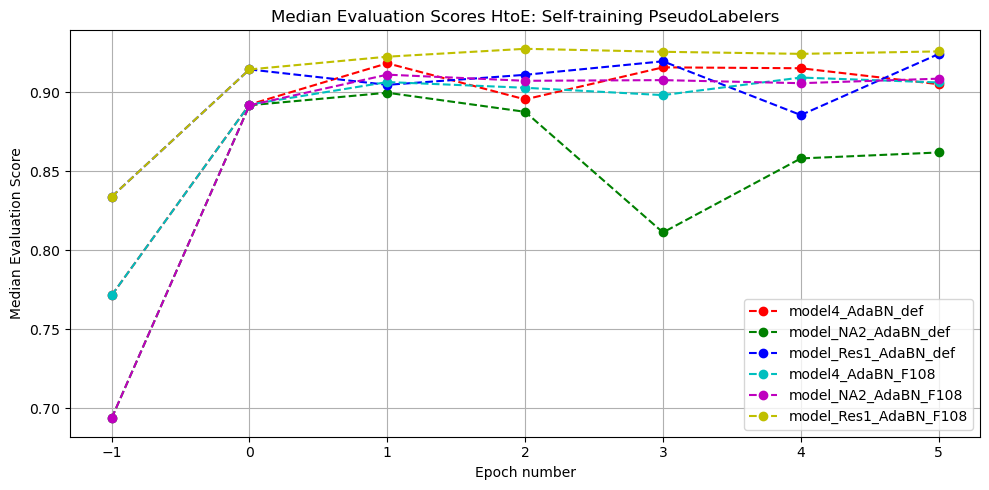

Transfer: RtoE


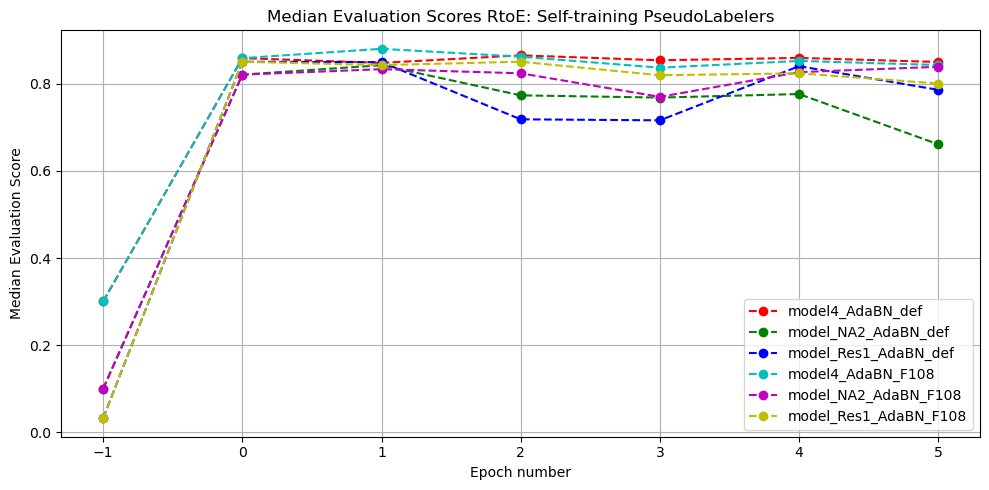

Transfer: VtoE


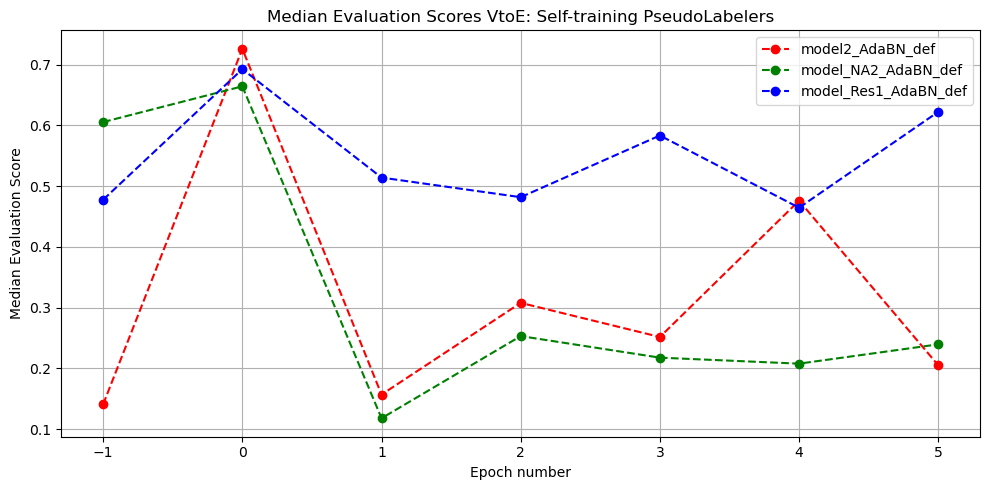

Transfer: EtoH


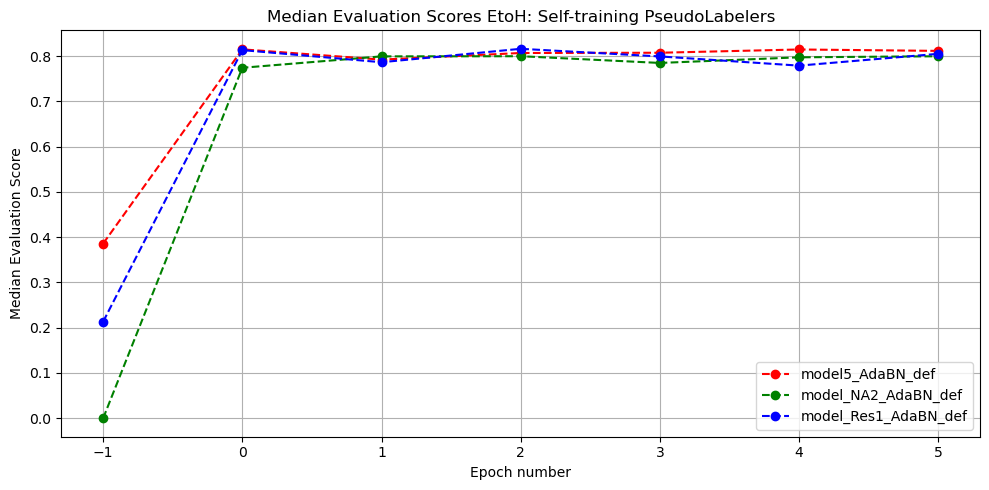

Transfer: RtoH


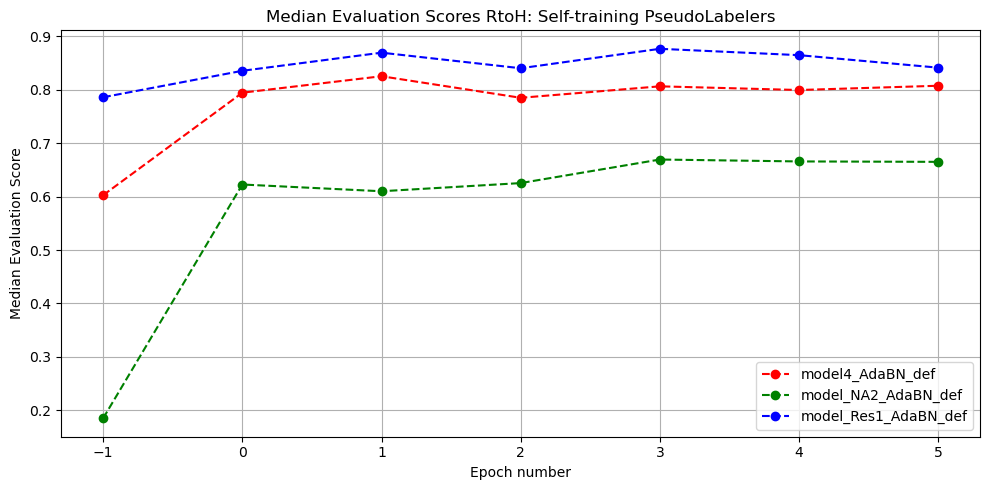

Transfer: VtoH


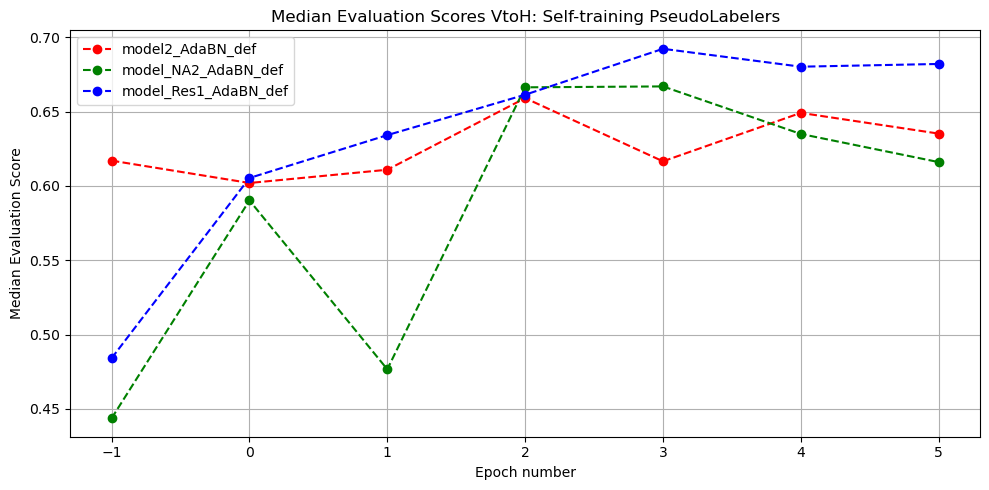

Transfer: EtoR


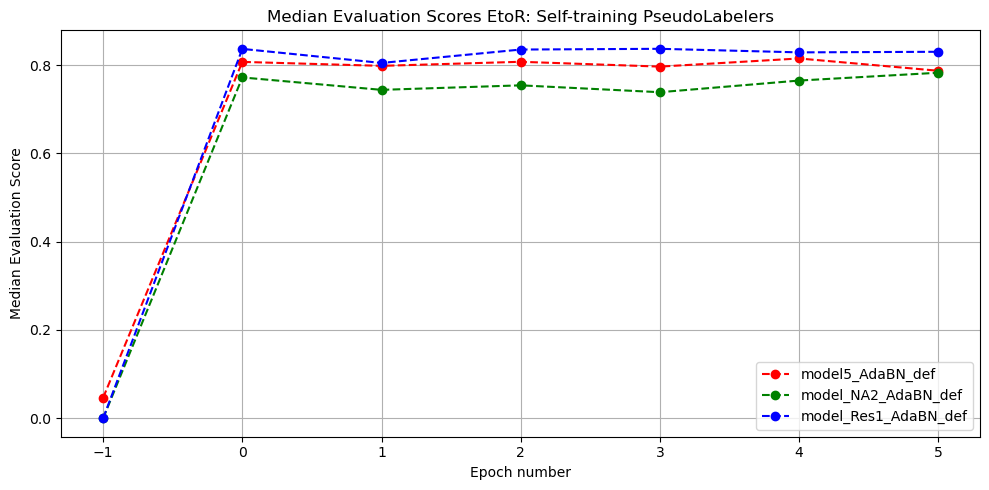

Transfer: HtoR


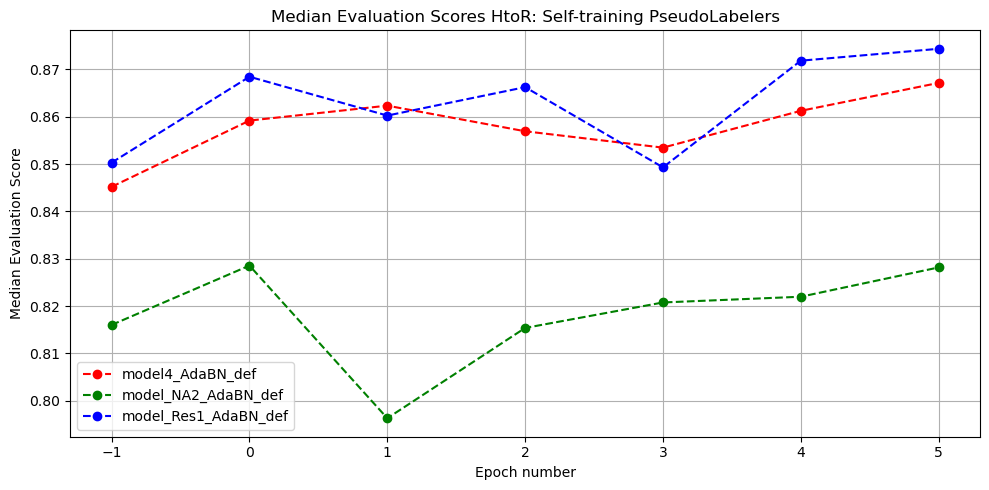

Transfer: VtoR


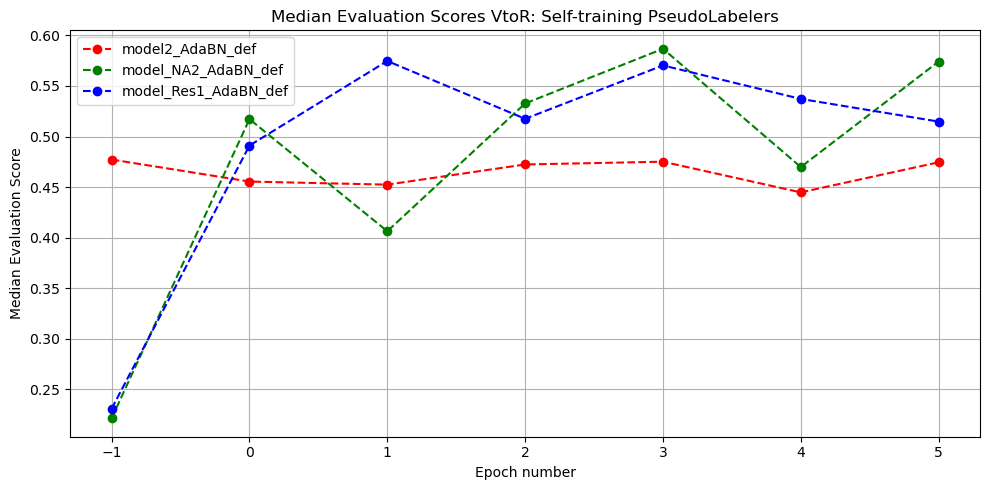

Transfer: EtoV


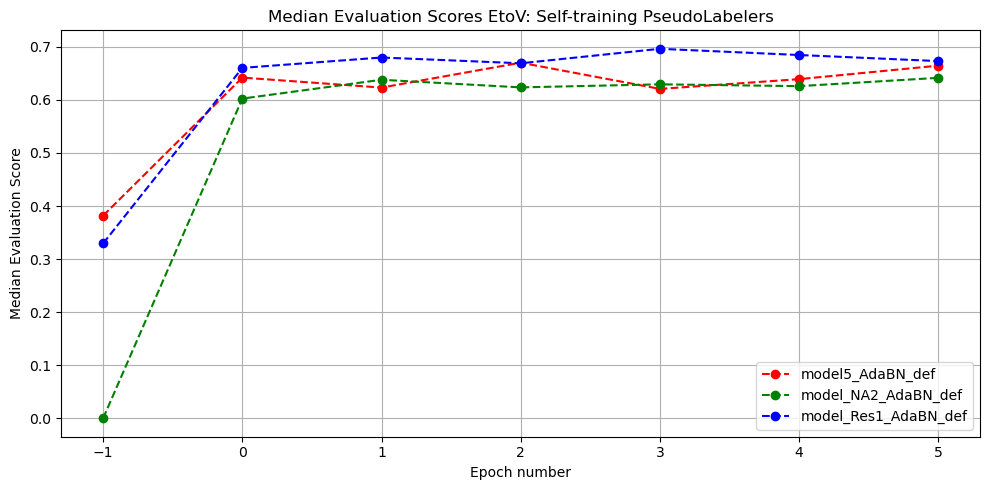

Transfer: HtoV


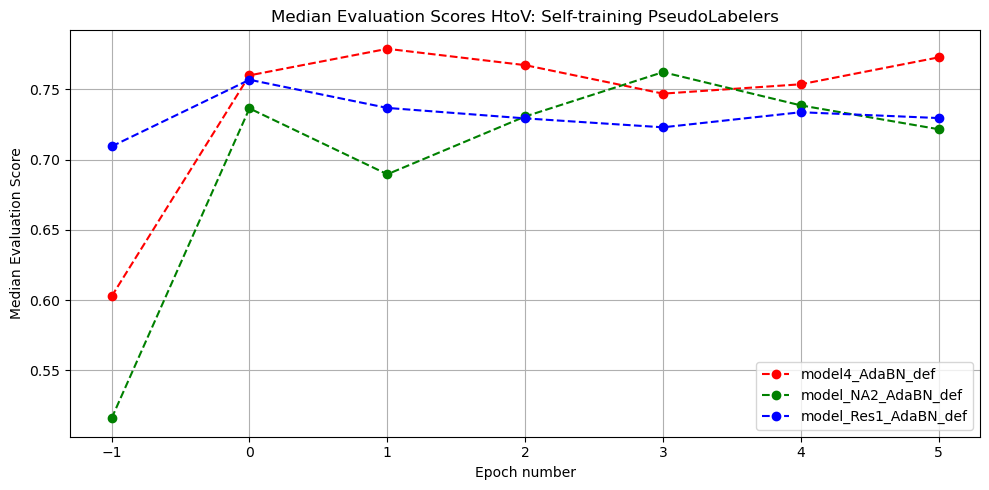

Transfer: RtoV


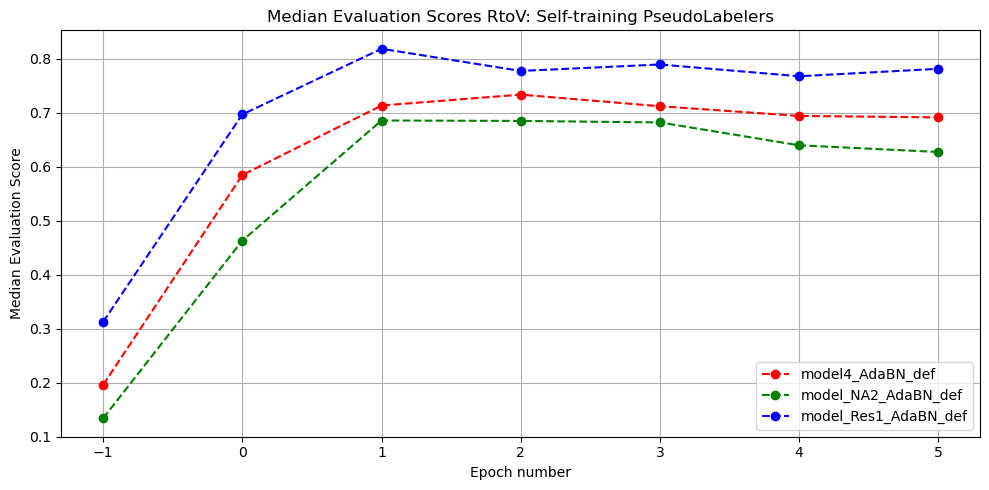

In [26]:

colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
best_epoch_per_transfer: Dict[str, Dict[str, int]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    best_epochs_per_model: Dict[str, int] = {}
    for i, model_name in enumerate(model_list):
        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        #label = None
        label = "_".join(model_name.split("_")[1:])
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
        else:
            epoch_ids = list(range(1, 6, 1))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        
        adabn_models_list = adabn_models.get(transfer, [])
        adabn_model_name = None
        for adabn_model in adabn_models_list:
            if adabn_model in model_name:
                adabn_model_name = adabn_model
                break
        assert adabn_model_name is not None, f"AdaBN model not found for {model_name}"
        pred_path_adabn = find_batchnorm_pred_path(adabn_model_name, adabn_base_path, perturbation="none", return_summary=True)
        median_eval_score_adabn= load_h5(pred_path_adabn, "F1_eval_median")[1]

        median_eval_scores.insert(0, median_eval_score_adabn)

        yaml_paths = list((pred_path_adabn.parent.parent.parent.parent / "checkpoints").glob("*.yaml"))
        assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
        yaml_path = yaml_paths[0]
        initial_model_name = Path(load_config_direct(yaml_path)[0]["model_cfg"]["source_checkpoint"]).parent.stem
        target = MODEL_ABBREVIATIONS_TO_DATASET[transfer[-1]]
        initial_pred_path = get_NA_prediction_path(
            model_name=initial_model_name,
            target=target,
            base_path=base_transfer_path,
            approach=direct_run_approach,
            run_id=direct_run_id,
        )
        eval_score_direct = load_h5(initial_pred_path, "hard_f1")
        median_eval_score_direct = np.median(eval_score_direct, axis=0)[1]
        
        median_eval_scores.insert(0, median_eval_score_direct)
        #median_eval_scores.insert(0, eval_direct_median[1])
        #epochs = list(range(0, 22, 2))
        # epochs = list(range(0, 11, 1))
        epochs = list(range(-1, 6, 1))
        #epochs = list(range(0, 6, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0

        best_epoch_id = median_eval_scores.index(max(median_eval_scores))
        best_epochs_per_model[model_name] = best_epoch_id
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)

    # adabn_models_list = adabn_models.get(transfer, [])
    # for i, model_name in enumerate(adabn_models_list):
    #     pred_path = find_batchnorm_pred_path(model_name, adabn_base_path, perturbation="none", return_summary=True)
    #     median_eval_score_adjusted = load_h5(pred_path, "F1_eval_median")[1]
    #     _ = plt.scatter([0], [median_eval_score_adjusted], marker='x', color=colours[i], label=model_name+"_AdaBN")


    best_epoch_per_transfer[transfer] = best_epochs_per_model

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()
